# Tutorial for closure repository

Below the simple implementation of predicting electron heat flux is discussed, along with best guidelines. 
We will keep it simple in this exercise and only introduce the Multi Layer Peceptron (MLP) model and not apply any smoothing to the data.

We start by importing the necessary libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging

from closure import trainers as tr
from closure import evaluation as ev

# Enable logging so training progress is visible in the notebook
logging.basicConfig(level=logging.INFO, force=True)

## Trainer class

Trainer class is the main class that is used to train the model. It is responsible for loading the data, preprocessing it, training the model, and evaluating it. The class is defined in `closure/trainers.py`. Before looking there you can play with few examples to get a feeling for it

The keyword arguments that it receives (kwargs) are split into dictionary which is broken into
* `work_dir`:         the directory where the results are saved
* `dataset_kwargs`:   keyword arguments that are passed to the dataset class. This prepares train, val and test datasets according to specifications
* `load_data_kwargs`: keyword arguments that are passed to the data loader. Data loader is in charge of sampling the data and creating the batches
* `model_kwargs`:     keyword arguments that are passed to the model class, including optimizers and architectures

### Dataset class

It helps if you have already looked at `examples/read_PIC.ipynb` to understand how to read data. The parameters we will require there are:

In [2]:
read_features_targets_kwargs = {'fields_to_read' :    {"B": True,"B_ext": False,"divB": False,"E": True,"E_ext": False,"rho": True,"J": True,
                                                      "P": True,"PI": True,"Heat_flux": False,"N": False,"Qrem": False}, # which fields to read
                                'request_features' :  ['rho_e', 'Bx', 'By', 'Bz', 'Vx_e', 'Vy_e', 'Vz_e', 'Ex', 'Ey', 'Ez'],  # what network needs to make predictions
                                'request_targets' :   ["Pxx_e", "Pyy_e","Pzz_e","Pxy_e","Pxz_e","Pyz_e"],                     # what we want to predict
                                'choose_species' :    ['e',None],   # which species to take
                                'choose_x' : [0,256], 'choose_y' : [0,256], 'verbose' : False  # which part of the domain to take. The full domain is 2048x2048 and is too heavy for the tutorial
                          } # make sure not to put a comma here, otherwise the object becomes a tuple rather than a dictionary which causes all sorts of problems

Now we construct the full dataset_kwargs dictionary which contains the following with the comments that explain each key:

In [3]:
dataset_kwargs = {'data_folder': "/volume1/scratch/share_dir/ecsim/",               # where the data is stored
                          'image_file_name_column' : 'filenames',                       # the column in the csv file that contains the image file names
                          'read_features_targets_kwargs' : read_features_targets_kwargs,
                          'train_sample' :  "/volume1/scratch/share_dir/brecht/sampling/turbulence/train.csv",  # this should be the path to the csv file that contains a list of training samples, each cell corresponds to local paths to the actual data relative to `data_folder`
                          'val_sample' :    "/volume1/scratch/share_dir/brecht/sampling/turbulence/val.csv",    # same but validation
                          'test_sample' :   "/volume1/scratch/share_dir/brecht/sampling/turbulence/test.csv",   # same but testing
                          'scaler_features' : True,    # Whether to normalize the features. It is called scaler because it rescales to 0 mean and 1 variance
                          'scaler_targets' : True,     # Whether to normalize the targets
                          'prescaler_targets' : ['log','log','log',None,None,None]  # If we want to transform the targets before training. The order in which they appear correspond to `request_targets` in `read_features_targets_kwargs``
                      }

To see what snapshots are taken as test sample

In [4]:
import pandas as pd
pd.read_csv(dataset_kwargs['test_sample'])

,filenames
0,peppe/data/MSH-Fields_006000.h5
1,peppe/data/MSH-Fields_006500.h5
2,peppe/data/MSH-Fields_007000.h5
3,peppe/data/MSH-Fields_007500.h5
4,peppe/data/MSH-Fields_014000.h5
5,peppe/data/MSH-Fields_014500.h5
6,peppe/data/MSH-Fields_015000.h5


The next step is to define `load_data_kwargs` which we feed to the data loader. 

Since the model we are using below works locally, the data is flattened automatically so that each cell in space and time is individual sample. This is done after splitting the data into train, validation and test sets. Because each cell is now a sample, we may choose to undersample the data to reduce the size of the dataset. This is done by setting the `subsample_rate` key in the `load_data_kwargs` dictionary. So as a result we will work with less data and the training will be faster. Of course, if we want to get best results we should use all the data.

In [5]:
load_data_kwargs={'train_loader_kwargs' : {'batch_size' : 512,      #training batch size
                                           'subsample_rate' : .2,   #subsample rate which defines a fraction of data that is used when sampling. 1 means all data is used
                                           'subsample_seed' : 42,   #seed for the subsampling
                                           'seed' : 42,             #seed for the random number generator
                                           'shuffle' : True},       #shuffle the training set
                    'val_loader_kwargs' : {'batch_size' : 512,        #validation batch size
                                           'subsample_rate' : .2, 
                                           'subsample_seed' : 42, 
                                           'shuffle' : False}}      # we don't need to shuffle the validation set

We are using Multi Layer Perceptron with 4 hidden layers and mostly `Tanh` activation functions. `ReduceLROnPlateau` scheduler is used, which essentially monitors 
validation loss and reduces learning rate if the loss does not decrease for a certain number of epochs. Notice that `early_stopping` may interfere with this policy

In [6]:
model_kwargs={'model': 'MLP',    # the model class name we want to use, check `closure/models.py` for available models
              'model_seed' : 42, # seed for the random initialization of the model
              'feature_dims' : [10, 60, 80, 50, 40, 6], # the dimensions of the layers in the model. The first element should be the number of `request_features` in `read_features_targets_kwargs` and the last element should be the number of `request_targets` in `read_features_targets_kwargs`
              'activations' : ['Tanh','Tanh','ReLU','Tanh', None], 
    'optimizer_kwargs': {'optimizer' : 'Adam',      # look up https://pytorch.org/docs/stable/generated/torch.optim.Adam.html#adam 
                         'lr' : 5e-4,               # learning rate
                         'criterion': 'MSELoss'},   # the loss function to optimize
    'scheduler_kwargs': {'scheduler' : 'ReduceLROnPlateau',  # look up https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
                         'mode' : 'min',  # the remainder are the arguments for the ReduceLROnPlateau scheduler
                         'factor' : 0.2, 
                         'patience' : 10, 
                         'cooldown' : 15 , 
                         'epochs' : 10,                 # number of epochs before stopping training
                         'early_stopping' : 20},        # number of epochs to tolerate without improvement
    'logger_kwargs':{'update_step': 1, 'show': True}}   # some details about how to log the training process

The lines below will create the Trainer object and train the model. The Trainer object will load the data from the original h5 files, convert it first to numpy, preprocess it and convert to torch tensors. The outputs will be saved in the `work_dir` directory.

This is the first time that we initalize the model and the enclosing directory so everything will be created from scratch. This operation may take a while, depending on the size of the dataset. In the future we will introduce the possibility of saving all the steps performed by datasets class and save it to a pickle file. 

In [7]:
work_dir = '/volume1/scratch/georgem/closure/models/dev/dev16/'  # you may have to create containing path before running the script (check in the source code). It is better to use absolute paths than relative paths for the operations below to work
                                                                            # the /dev16/ folder on the other hand will be definitely created by the trainer so you don't need to create it
! rm -rf {work_dir}  # This will delete the previously existing model
trainer = tr.Trainer(work_dir=work_dir,   # where the model will be saved
                     dataset_kwargs=dataset_kwargs, load_data_kwargs=load_data_kwargs, model_kwargs=model_kwargs)

INFO:closure.trainers:Creating a new configuration file: /volume1/scratch/georgem/closure/models/dev/dev16/config.json
/users/cpa/georgem/miniforge3/envs/closure-test/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
INFO:closure.trainers: 
INFO:closure.trainers:===Logging to /volume1/scratch/georgem/closure/models/dev/dev16//training.log on level 20, @ self.rank=None, self.local_rank=None
INFO:closure.trainers:host: haydn.esat.kuleuven.be, self.device=device(type='cpu') ===
INFO:closure.trainers: 
INFO:closure.d

In [8]:
trainer.train_dataset.request_features

['rho_e', 'Bx', 'By', 'Bz', 'Vx_e', 'Vy_e', 'Vz_e', 'Ex', 'Ey', 'Ez']

Above the code returns the operations and the specific python files used to run the scripts. 

Other useful information can be found there. We can see what model was initialized, where the files are sourced and the shape of the data

As can be seen now the work directory will contain the following files, including 
* the configuration file which inherits the inputs to the trainer class
* training log that you see above with timed outputs
* normalization parameters that are used to normalize the data:

In [9]:
! ls {work_dir}

config.json  training.log  X.pkl  y.pkl


In this notebook we are building up to creation of the `config.json` file, so we do it by running the training class. In the future you will see that all that you need is a `config.json` file.

What has been created is a trainer class instance, equipped with the loaders and processed datasets that received configurations that we specified above:

In [10]:
print(f"trainer work dir: \t\t{trainer.work_dir}")
print(f"trainer class instance: \t{trainer}")
print(f"trainer loader: \t\t{trainer.train_loader}")
print(f"train dataset features shape: \t {trainer.train_dataset.features.shape}")
print(f"train dataset targets shape: \t{trainer.train_dataset.targets.shape}")

trainer work dir: 		/volume1/scratch/georgem/closure/models/dev/dev16/
trainer class instance: 	<closure.trainers.Trainer object at 0x7fcb1ef817c0>
trainer loader: 		<closure.dataloaders.ChannelDataLoader object at 0x7fca995715b0>
train dataset features shape: 	 torch.Size([1048576, 10])
train dataset targets shape: 	torch.Size([1048576, 6])


In [11]:
import torch
torch.mean(trainer.train_dataset.features, dim=0), torch.std(trainer.train_dataset.features, dim=0)

(tensor([ 1.6706e-08, -1.1176e-08,  2.0955e-09, -1.7462e-10, -6.9849e-10,
          1.6531e-08,  2.8231e-09, -5.1223e-09,  4.4238e-09,  3.6089e-09]),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000]))

In [12]:
import torch
torch.mean(trainer.val_dataset.features, dim=0), torch.std(trainer.val_dataset.features, dim=0)

(tensor([ 0.1214, -0.2076,  0.0554, -0.0732,  0.2455, -0.1087, -0.0684,  0.0879,
          0.1847, -0.3582]),
 tensor([0.8271, 1.1260, 0.8411, 1.0146, 0.8598, 0.8141, 1.2448, 0.9926, 0.9901,
         1.0612]))

Now we are ready to train, since we already have the trainer class in RAM. Notice that the performance will depend on the type of CPU/GPU you are using

In [13]:
trainer.fit()

INFO:closure.trainers:Prior to fit: RAM memory % used: 7.0, RAM Used (GB): 18.931634176, process RAM usage (GB): 0.8816337585449219
INFO:closure.models:Each forward pass had 410 train batches.
INFO:closure.models:Number of samples per batch: len(next(iter(train_loader))[0]) = 512
INFO:closure.models:Epoch 1/10 | Train loss: 1.1150e-01 | Val loss: 2.4670e+00 | Time/epoch: 4.874 s | Time/epoch_train: 3.099 s | Learn rate: [0.0005]
INFO:closure.models:Epoch 2/10 | Train loss: 2.5440e-02 | Val loss: 2.3133e+00 | Time/epoch: 4.967 s | Time/epoch_train: 3.034 s | Learn rate: [0.0005]
INFO:closure.models:Epoch 3/10 | Train loss: 1.9590e-02 | Val loss: 2.1583e+00 | Time/epoch: 5.097 s | Time/epoch_train: 3.159 s | Learn rate: [0.0005]
INFO:closure.models:Epoch 4/10 | Train loss: 1.7604e-02 | Val loss: 2.0893e+00 | Time/epoch: 5.24 s | Time/epoch_train: 3.056 s | Learn rate: [0.0005]
INFO:closure.models:Epoch 5/10 | Train loss: 1.6576e-02 | Val loss: 2.0400e+00 | Time/epoch: 4.99 s | Time/epoch

1.9616798999832898

In [14]:
! ls {work_dir}

config.json  loss_dict.pkl  model.pth  training.log  X.pkl  y.pkl


At this point we have not converged yet, but we can see that the loss is decreasing. 

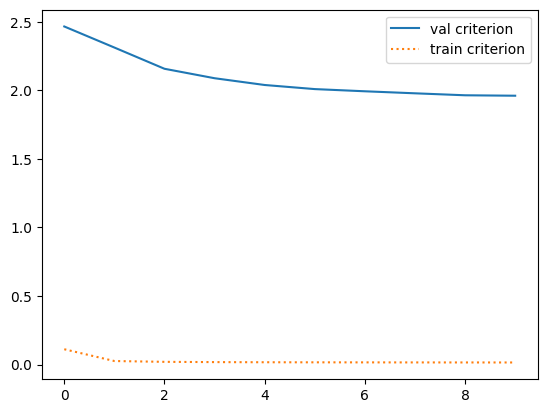

In [15]:
import matplotlib.pyplot as plt
for key, val_loss in trainer.model.val_loss_.items():
    plt.plot(val_loss, label=f'val {key}')
for key, val_loss in trainer.model.train_loss_.items():
    plt.plot(val_loss, label=f'train {key}', linestyle=':')
#plt.ylim(0, 8e-1)
plt.legend()
plt.show()

### Multiple runs in the same trainer folder

We see a severe case of overfitting since, while both training and validation losses are decreasing, the loss on the validation set is several orders of magnitude higher than the training loss. This model is not expected to work well. The most likely explanation for this is lack of data in this case.

Thus, it makes sense to try using at least all the data that was in the 256x256 portion of the images. In other words, we should set `subsample_rate` to 1.0.

In [16]:
load_data_kwargs={'train_loader_kwargs' : {'batch_size' : 512,      #training batch size
                                           'subsample_rate' : 1,   #subsample rate which defines a fraction of data that is used when sampling. 1 means all data is used
                                           'subsample_seed' : 42,   #seed for the subsampling
                                           'seed' : 42,             #seed for the random number generator
                                           'shuffle' : True},       #shuffle the training set
                    'val_loader_kwargs' : {'batch_size' : 512,        #validation batch size
                                           'subsample_rate' : 1, 
                                           'subsample_seed' : 42, 
                                           'shuffle' : False}}      # we don't need to shuffle the validation set

Now it is time to introduce how to run multiple runs in the same trainer folder. This is useful when you want to compare different models or hyperparameters. This operation is possible as long as you don't change the input data. If you change the dataset, you should create a new trainer in a separate folder to avoid issues associated with normalization that would be not consistent with the previous runs (the ones stored in `X.pkl` and `y.pkl` files).

Essentially, to make new runs you need to take previous config file and change the parameters you want to change. In this case we are changing data loader. This is very convenient when doing parametric studies, optimizing parameters such as learning rate, batch size, number of layers, etc. This can also be done automatically with Bayesian parameter optimizers, such as Optuna. 

In [17]:
import copy  # because configurations are a dictionary we must use deepcopy to avoid changing the original configuration
config = copy.deepcopy(trainer.config)
config['run'] = 'nosubsample'
config['load_data_kwargs'] = load_data_kwargs

Since we are working with more data you should expect the training to take longer.  

In [18]:
trainer.fit(config=config)

INFO:closure.trainers:Comprehending the configuration settings
INFO:closure.models:CUDA available: False
INFO:closure.models:Initialized model: MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=10, out_features=60, bias=True)
    (1): Tanh()
    (2): Linear(in_features=60, out_features=80, bias=True)
    (3): Tanh()
    (4): Linear(in_features=80, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=40, bias=True)
    (7): Tanh()
    (8): Linear(in_features=40, out_features=6, bias=True)
  )
)
INFO:closure.models:DDP not available, using single GPU: None
INFO:closure.models:Loss function: MSELoss()
INFO:closure.models:Optimizer: Adam with params: {'lr': 0.0005}
INFO:closure.models:Scheduler: ReduceLROnPlateau with params: {'mode': 'min', 'factor': 0.2, 'patience': 10, 'cooldown': 15}
INFO:closure.models:Training configuration complete for: <closure.models.PyNet object at 0x7fca993dbef0>


0.5859834404254798

Notice that now there is a new sub-folder that was created:

In [19]:
! ls {work_dir}
! ls {work_dir}/nosubsample # the sub-folder contains the corresponding model, its own configuration and the training logs (run.log) specific to this run. The loss history is stored in loss_dict.pkl

config.json  loss_dict.pkl  model.pth  nosubsample  training.log  X.pkl  y.pkl
config.json  loss_dict.pkl  model.pth  run.log


In [20]:
print(f"work directory: {trainer.work_dir}")
print(f"{trainer.run = }")

work directory: /volume1/scratch/georgem/closure/models/dev/dev16/
trainer.run = 'nosubsample'


The model we get as a result still overfits but at least we can do the first tests

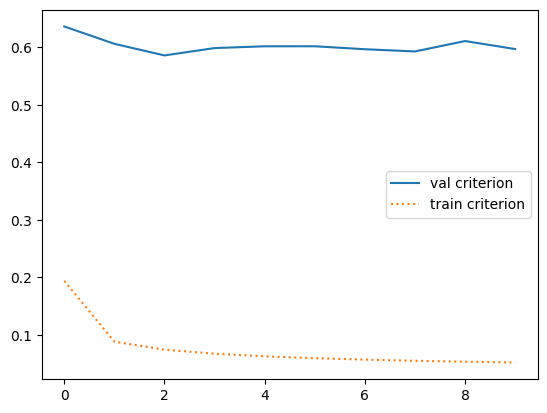

In [21]:
import matplotlib.pyplot as plt
for key, val_loss in trainer.model.val_loss_.items():
    plt.plot(val_loss, label=f'val {key}')
for key, val_loss in trainer.model.train_loss_.items():
    plt.plot(val_loss, label=f'train {key}', linestyle=':')
#plt.ylim(0, 8e-1)
plt.legend()
plt.show()

### Evaluation of the model

Evaluation of the model can be made based on the test loss which can be computed after predicting the targets on the test set. The recommended approach is `ev.transform_targets()` which returns un-normalized ground truth and predictions. The older `ev.pred_ground_targets()` is still available but deprecated.

In [22]:
prediction, ground_truth, list_of_target_indices = ev.pred_ground_targets(trainer)

The function pred_ground_targets is deprecated. Use transform_targets instead.
Total loss 0.6001187562942505
Loss for channel 0: Pxx_e, loss = 0.12189637124538422
Loss for channel 1: Pyy_e, loss = 0.15065822005271912
Loss for channel 2: Pzz_e, loss = 0.17983995378017426
Loss for channel 3: Pxy_e, loss = 1.1000903844833374
Loss for channel 4: Pxz_e, loss = 1.3009027242660522
Loss for channel 5: Pyz_e, loss = 0.7473245859146118


We see that performance on the off-diagonal elements is much worse than on the diagonal elements

Important thing to note is that the outputs of this function are still in the form of the normalized scaled data that the neural network was using. So to correctly interpret they have to be re-scaled properly. Fortunately there is a plotting function that has already been written for this purpose.

invfunc = <ufunc 'exp'>


/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 19 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 20 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 21 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 22 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/vol

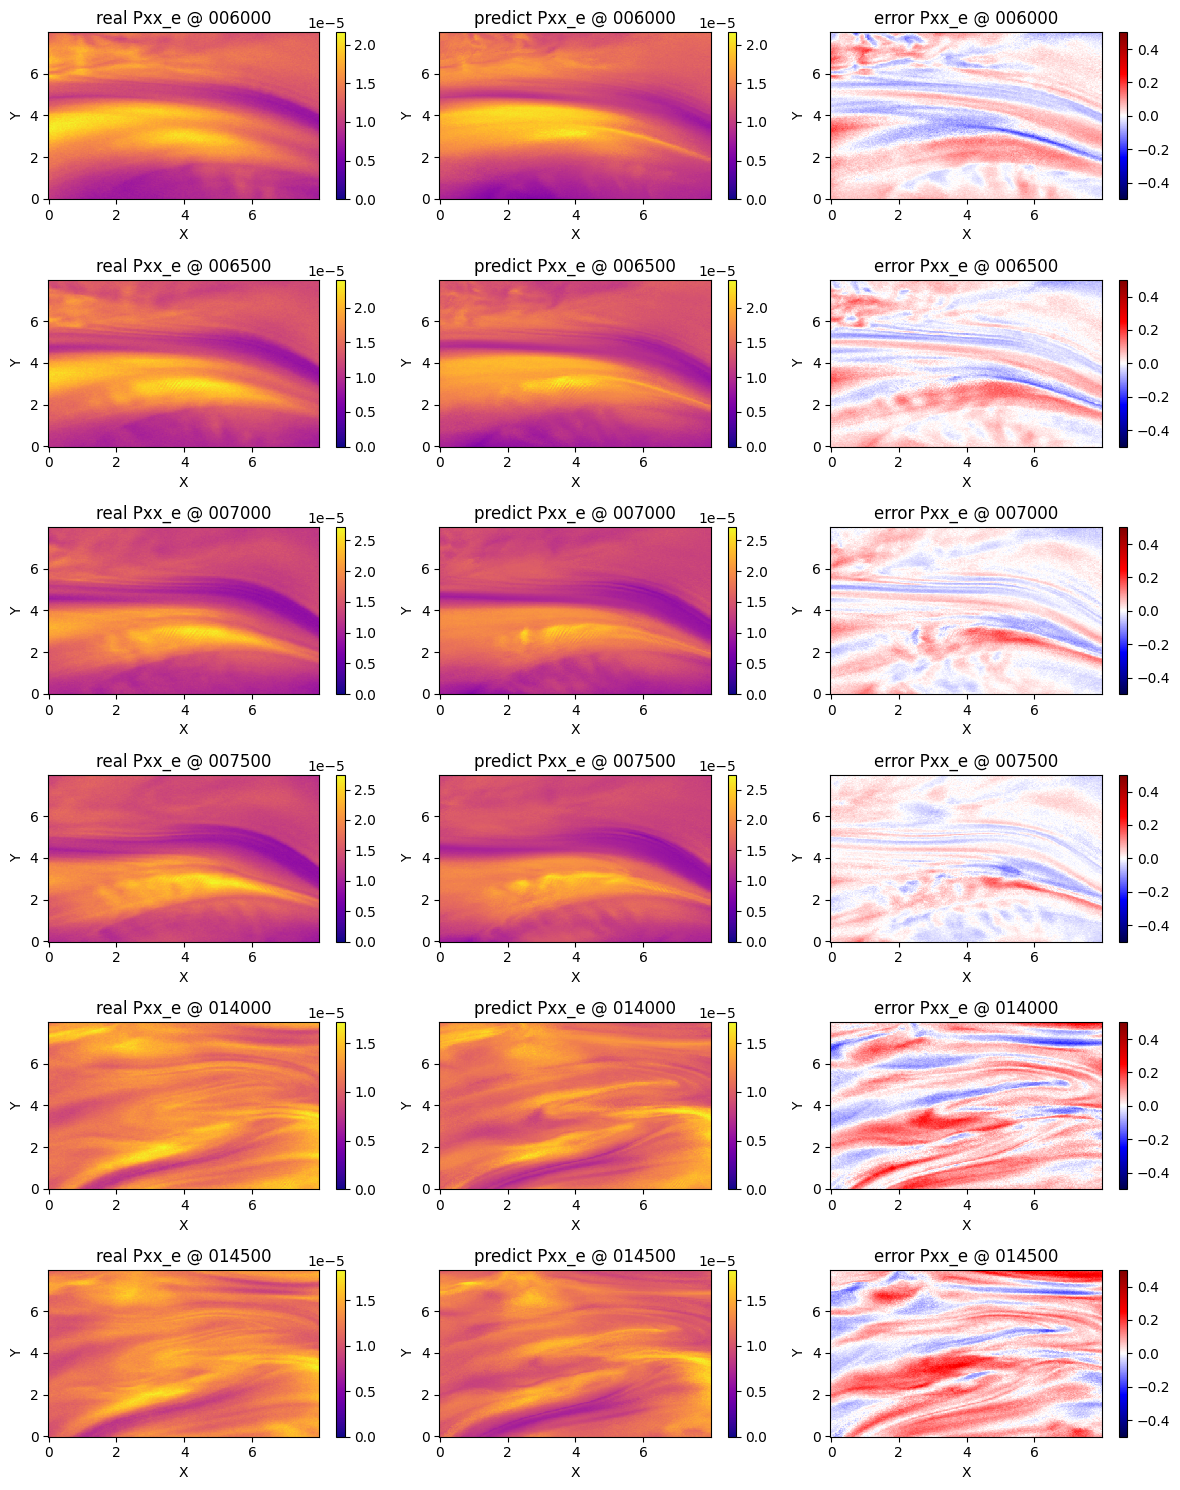

In [23]:
from closure.visualization import plot_pred_targets
plot_pred_targets(trainer, 'Pxx_e', prediction, ground_truth, list_of_target_indices, figsize=(12,15))

We see that some large scale structures are sort-of predicted ok, but the details are not, especially in fully-developed case. To get better feeling for how `plot_pred_targets` works please see the source code

invfunc = <function plot_pred_targets.<locals>.<lambda> at 0x7fca98fe20c0>


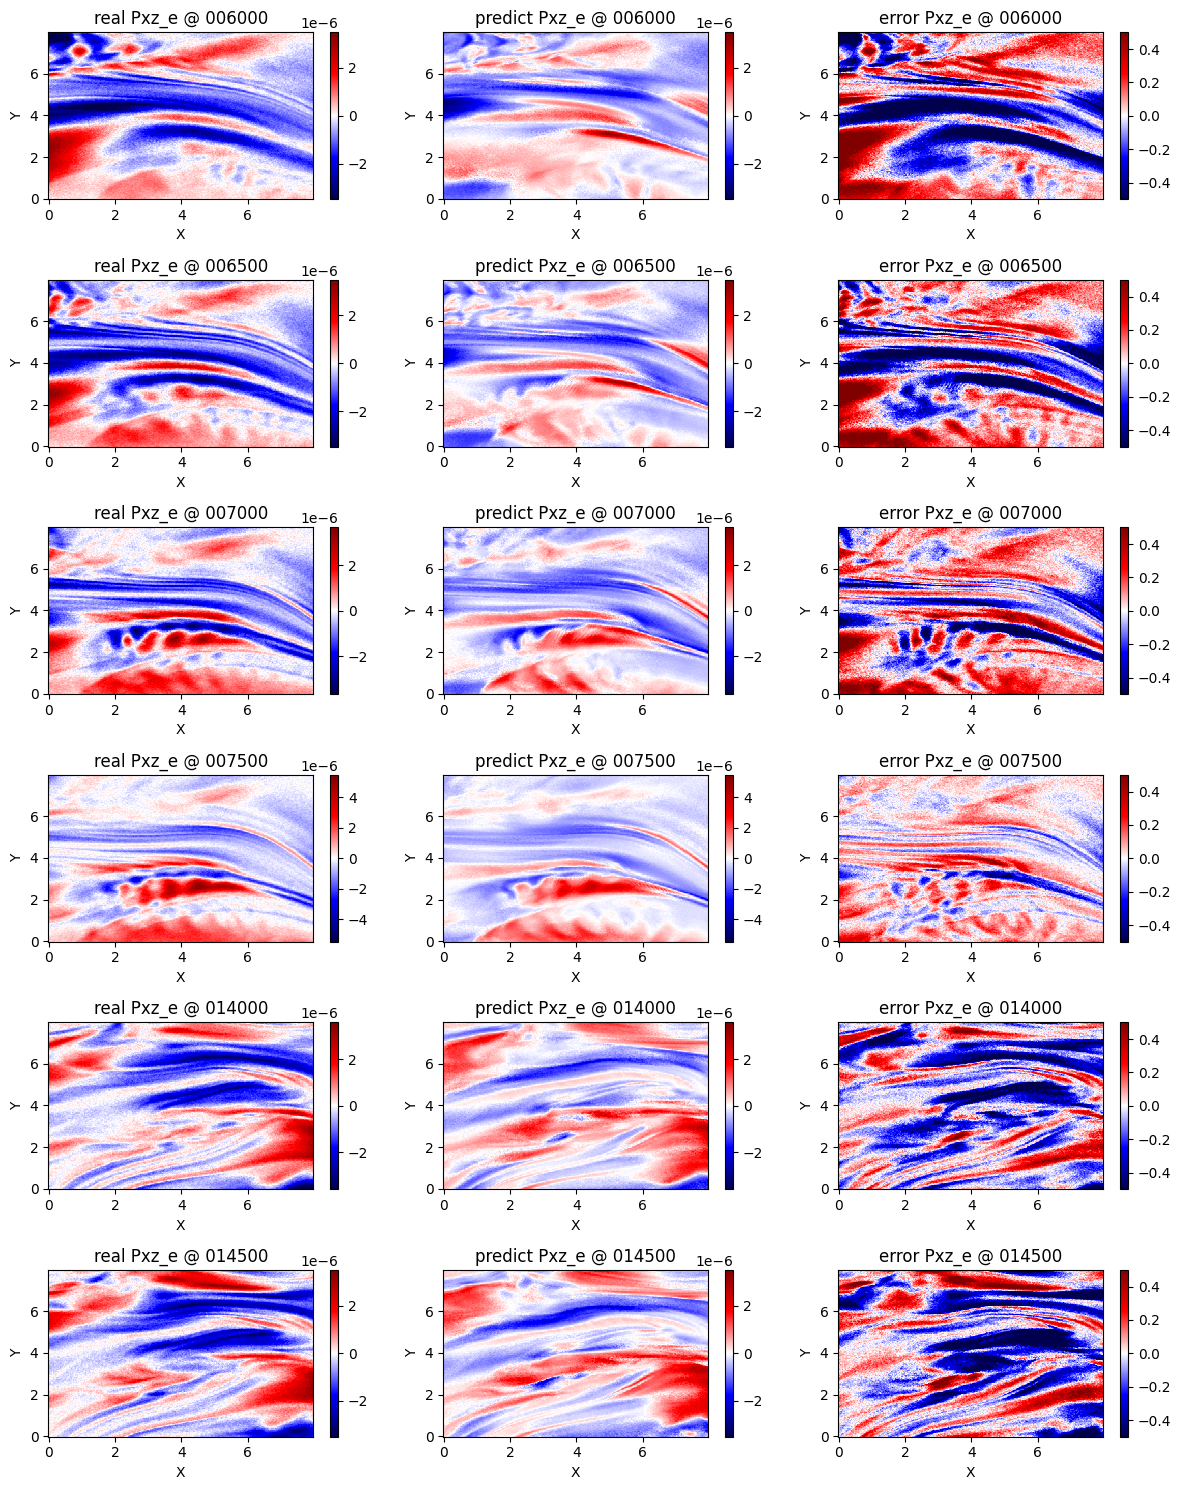

In [24]:
plot_pred_targets(trainer, 'Pxz_e', prediction, ground_truth, list_of_target_indices, figsize=(12,15))

Indeed, the off-diagonal elements are not predicted well. The question about which data to use as training is an important one

## Reloading previous runs
Trainer class is equipped with a function that allows re-loading the specific model in use. At the moment we have two networks, one in the parent folder (which we do not recommend in future) and one in the sub-folder. We will load the model from the parent folder

In [25]:
trainer.load_run(f"./") # load the run which is in the parent directory (runs are always defined relative to the work_dir)

INFO:closure.trainers: 
INFO:closure.trainers:===Logging to /volume1/scratch/georgem/closure/models/dev/dev16//.//run.log on level 20, @ self.rank=None, self.local_rank=None
INFO:closure.trainers:host: haydn.esat.kuleuven.be, self.device=device(type='cpu') ===
INFO:closure.trainers: 
INFO:closure.trainers:==========Config file /volume1/scratch/georgem/closure/models/dev/dev16/./config.json found, logging to /volume1/scratch/georgem/closure/models/dev/dev16//.//run.log========
INFO:closure.trainers:Comprehending the configuration settings
INFO:closure.models:CUDA available: False
INFO:closure.models:Initialized model: MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=10, out_features=60, bias=True)
    (1): Tanh()
    (2): Linear(in_features=60, out_features=80, bias=True)
    (3): Tanh()
    (4): Linear(in_features=80, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=40, bias=True)
 

In [26]:
prediction, ground_truth, list_of_target_indices = ev.pred_ground_targets(trainer)

The function pred_ground_targets is deprecated. Use transform_targets instead.
Total loss 1.6244724988937378
Loss for channel 0: Pxx_e, loss = 1.1615209579467773
Loss for channel 1: Pyy_e, loss = 1.0581670999526978
Loss for channel 2: Pzz_e, loss = 1.720133900642395
Loss for channel 3: Pxy_e, loss = 2.2334787845611572
Loss for channel 4: Pxz_e, loss = 2.0704967975616455
Loss for channel 5: Pyz_e, loss = 1.5030384063720703


As expected, the first model has relatively poor performance. 

### Comparing metrics accross runs/ trainer directories

Loss functions are not so meaningful, since they are only bounded from below. A better metric is the `r2_score` which is a measure of how well the model is doing compared to a simple mean prediction.

Below we use a tool which would also work when comparing two separate work directories, but here we use it to compare two runs in the same `work_dir`. In general the code will load the separate work directories and the corresponding runs

The line below will take long time to run. In the future we will consider saving the dataset to a pickle file to avoid this as stated earlier, but also perhaps precomputing the metrics and saving them to a separate csv file

In [27]:
loss = ev.compare_metrics(work_dirs=[work_dir, work_dir], runs=['./','nosubsample'], metric=['r2'])

INFO:closure.trainers: 
INFO:closure.trainers:===Logging to /volume1/scratch/georgem/closure/models/dev/dev16//training.log on level 20, @ self.rank=None, self.local_rank=None
INFO:closure.trainers:host: haydn.esat.kuleuven.be, self.device=device(type='cpu') ===
INFO:closure.trainers: 
INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /volume1/scratch/share_dir/brecht/sampling/turbulence/train.csv
INFO:closure.read_pic:About to transpose array with shape (16, 10, 256, 256)
INFO:closure.read_pic:About to transpose array with shape (16, 6, 256, 256)
INFO:closure.datasets:Data shape - Features: (1048576, 10), Targets: (1048576, 6)
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/dev16//X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Applied log to targets channel 0
INFO:closure.datasets:Applied log to targets channel 1
INFO:closure.datasets:Applied 

This creates a convenient `loss` pandas DataFrame

In [28]:
loss

,work_dir,exp,run,total_loss,total_r2,Pxx_e,Pxx_e_r2,Pyy_e,Pyy_e_r2,Pzz_e,Pzz_e_r2,Pxy_e,Pxy_e_r2,Pxz_e,Pxz_e_r2,Pyz_e,Pyz_e_r2
0,/volume1/scratch/georgem/closure/models/dev/de...,dev16,./,1.6244725,-1.3549309,1.161521,-3.0142555,1.0581671,-3.68755,1.7201339,-15.114105,2.2334788,-3.711893,2.0704968,-0.7620226,1.5030384,-0.51298225
1,/volume1/scratch/georgem/closure/models/dev/de...,dev16,nosubsample,0.60011876,0.20132583,0.12189637,0.76665837,0.15065822,0.7284581,0.17983995,0.68689454,1.1000904,-0.3712448,1.3009027,-0.5534457,0.7473246,0.1254865


If you would like to create a more slide friendly plot with the text that can be copy pasted, you can use the following code:

In [29]:
loss2 = loss.copy()
loss2['work_dir'] = loss2['work_dir'].str.split('/').str[-1]
loss2['work_dir'].iloc[0] = 'subsample'
loss2['work_dir'].iloc[1] = 'full'
print(loss2.to_string(index=False))

work_dir   exp         run total_loss   total_r2      Pxx_e   Pxx_e_r2      Pyy_e  Pyy_e_r2      Pzz_e   Pzz_e_r2     Pxy_e   Pxy_e_r2     Pxz_e   Pxz_e_r2     Pyz_e    Pyz_e_r2
         dev16          ./  1.6244725 -1.3549309   1.161521 -3.0142555  1.0581671  -3.68755  1.7201339 -15.114105 2.2334788  -3.711893 2.0704968 -0.7620226 1.5030384 -0.51298225
         dev16 nosubsample 0.60011876 0.20132583 0.12189637 0.76665837 0.15065822 0.7284581 0.17983995 0.68689454 1.1000904 -0.3712448 1.3009027 -0.5534457 0.7473246   0.1254865


/tmp/ipykernel_3507398/4219883570.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  loss2['work_dir'].iloc[0] = 'subsample'
/tmp/ipykernel_3507398/4219883570.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_in

Comparing loss functions

Text(0.5, 0, 'experiments')

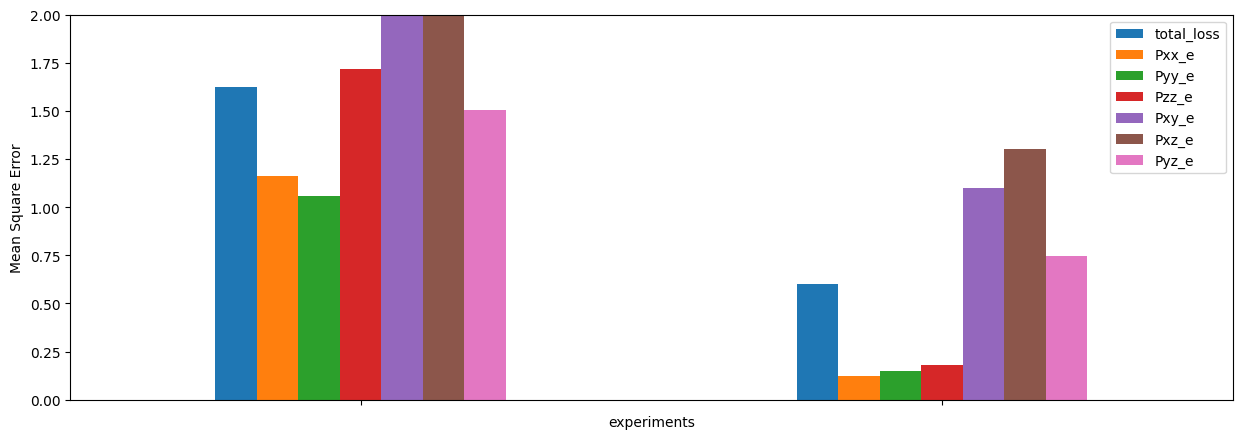

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
selected_columns = loss2.columns[~loss2.columns.str.endswith('_r2')]
selected_data = loss2[selected_columns]
columns = selected_data.columns[loss2.columns.get_loc('total_loss'):]

x = list(loss2['work_dir'])
df = pd.DataFrame({key: value for key, value in zip(columns, loss2[columns].values.T.tolist())}, index=list(x), 
                  dtype=float)
fig = plt.figure(figsize=(15, 5)) 
df.plot.bar(rot=90, ax=fig.gca())
plt.ylim([0,2])
plt.ylabel('Mean Square Error')
plt.xlabel('experiments')

Comparing $r^2$ metric

Text(0.5, 0, 'experiments')

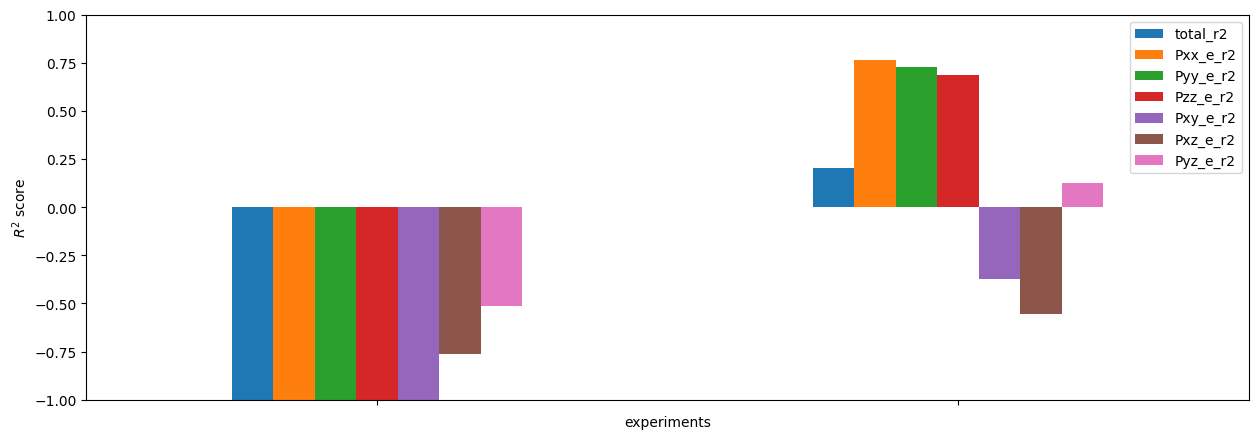

In [31]:
columns_r2 = loss2.columns[loss2.columns.str.endswith('_r2')]
#selected_data_r2 = loss2[selected_columns_r2]
#columns_r2 = selected_data_r2.columns[loss2.columns.get_loc('total_r2'):]
x = list(loss2['work_dir'])

df = pd.DataFrame({key: value for key, value in zip(columns_r2, loss2[columns_r2].values.T.tolist())}, index=list(x), 
                  dtype=float)
fig = plt.figure(figsize=(15, 5)) 
df.plot.bar(rot=90, ax=fig.gca())
plt.ylim([-1,1])
plt.ylabel(r'$R^2$ score')
plt.xlabel('experiments')

# Reloading the trainer

Suppose the training has been performed and you would like to reload the trainer without initializing everything from scratch. 

The following can be run without the need of running any of the previous lines in this notebook assuming that the models already exist (the notebook has already been run once). In fact at this point you can re-load the notebook emptying the RAM.

When providing work directory to the trainer only, it will automatically check if there is a configuration file existing. If there is a configuration file, it will load the trainer with the same parameters as before.

In [32]:
from closure import trainers as tr
from closure import evaluation as ev

work_dir = '/volume1/scratch/georgem/closure/models/dev/dev16/' 
trainer = tr.Trainer(work_dir=work_dir)
trainer.load_run(f'./nosubsample') # load the run which is in the parent directory (runs are always defined relative to the work_dir)

INFO:closure.trainers: 
INFO:closure.trainers:===Logging to /volume1/scratch/georgem/closure/models/dev/dev16//training.log on level 20, @ self.rank=None, self.local_rank=None
INFO:closure.trainers:host: haydn.esat.kuleuven.be, self.device=device(type='cpu') ===
INFO:closure.trainers: 
INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /volume1/scratch/share_dir/brecht/sampling/turbulence/train.csv
INFO:closure.read_pic:About to transpose array with shape (16, 10, 256, 256)
INFO:closure.read_pic:About to transpose array with shape (16, 6, 256, 256)
INFO:closure.datasets:Data shape - Features: (1048576, 10), Targets: (1048576, 6)
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/dev16//X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Applied log to targets channel 0
INFO:closure.datasets:Applied log to targets channel 1
INFO:closure.datasets:Applied 

We can verify that we have the right model by running the same code as before:

The function pred_ground_targets is deprecated. Use transform_targets instead.
Total loss 0.6001187562942505
Loss for channel 0: Pxx_e, loss = 0.12189637124538422
Loss for channel 1: Pyy_e, loss = 0.15065822005271912
Loss for channel 2: Pzz_e, loss = 0.17983995378017426
Loss for channel 3: Pxy_e, loss = 1.1000903844833374
Loss for channel 4: Pxz_e, loss = 1.3009027242660522
Loss for channel 5: Pyz_e, loss = 0.7473245859146118
invfunc = <ufunc 'exp'>


/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 19 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 20 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 21 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/volume1/scratch/georgem/closure/closure/visualization.py:238: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1500 with 22 Axes> than <Figure size 600x750 with 2 Axes> which fig.colorbar is called on.
  f.colorbar(im, ax=axes)
/vol

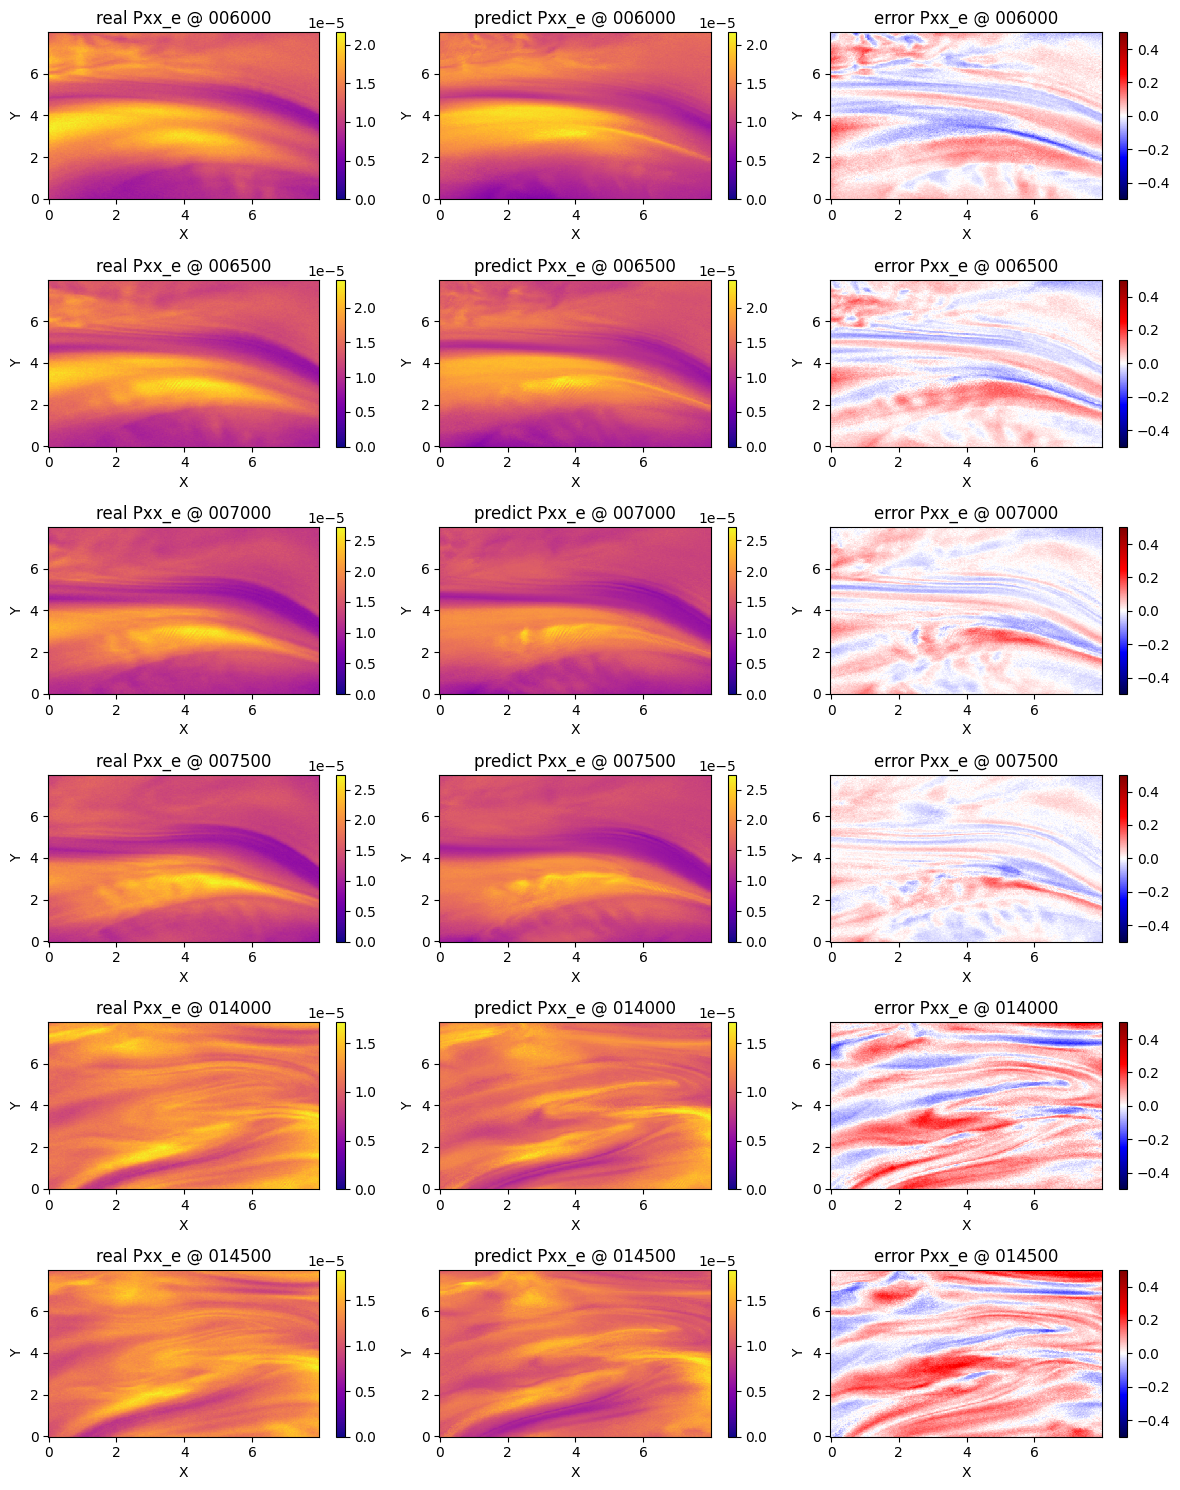

In [33]:
prediction, ground_truth, list_of_target_indices = ev.pred_ground_targets(trainer)
plot_pred_targets(trainer, 'Pxx_e', prediction, ground_truth, list_of_target_indices, figsize=(12,15))